In [5]:
# To extract the split zip files, run these commands in terminal:
# cd /path/to/your/project
# cat train.zip.* > train_combined.zip
# unzip train_combined.zip -d data/
# 
# This creates: data/train/ (images) and data/trainLabels.csv (labels)

import os
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# --- 1. Data Loading and Preprocessing ---

# Define paths
image_folder = '../data/train_images'  # Path to extracted training images
csv_file_path = '../data/train.csv'  # Path to the labels CSV file

# Function to load images and labels
def load_data(image_folder, csv_file, img_size=(224, 224)):
    """
    Loads images and labels from a folder and a CSV file.
    Resizes images and prepares data for the CNN.
    """
    labels_df = pd.read_csv(csv_file)
    
    images = []
    labels = []
    
    # Create a dictionary for quick label lookup
    label_map = {str(row['id_code']): row['diagnosis'] for index, row in labels_df.iterrows()}

    for file_name in os.listdir(image_folder):
        file_path = os.path.join(image_folder, file_name)
        if os.path.isfile(file_path):
            base_name = os.path.splitext(file_name)[0]
            
            if base_name in label_map:
                img = cv2.imread(file_path)
                if img is not None:
                    img = cv2.resize(img, img_size)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    images.append(img)
                    labels.append(label_map[base_name])
                    
    return np.array(images), np.array(labels)

# Load the data
try:
    images, labels = load_data(image_folder, csv_file_path)
    print(f"Loaded {len(images)} images and {len(labels)} labels.")
except FileNotFoundError:
    print(f"Error: Could not find the CSV file at '{csv_file_path}' or the image folder at '{image_folder}'.")
    print("Please make sure the paths are correct.")
    # You might want to stop execution here if files are not found
    images, labels = [], []

if len(images) > 0:
    # Normalize images
    images = images / 255.0

    # One-hot encode labels
    labels = to_categorical(labels, num_classes=5)

    # Split data into training, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(
        images, labels, test_size=0.3, random_state=42, stratify=labels
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Test samples: {len(X_test)}")


    # --- 2. Data Augmentation ---

    # Create an ImageDataGenerator for data augmentation
    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Create the augmented data generator
    train_generator = datagen.flow(X_train, y_train, batch_size=32)

Loaded 639 images and 639 labels.
Training samples: 447
Validation samples: 96
Test samples: 96


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# --- 3. CNN Model Architecture ---

def create_cnn_model(input_shape, num_classes):
    """
    Creates a baseline CNN model.
    """
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        
        Flatten(),
        
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax') # Use softmax for multi-class classification
    ])
    
    return model

if 'images' in locals() and len(images) > 0:
    # Get input shape and number of classes from the data
    input_shape = X_train.shape[1:]
    num_classes = y_train.shape[1]

    # Create the model
    model = create_cnn_model(input_shape, num_classes)

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Print model summary
    model.summary()


    # --- 4. Model Training ---

    # Calculate class weights to handle imbalance
    # Note: y_train is one-hot encoded, so we need to convert it back to integer labels for this function
    y_train_integers = np.argmax(y_train, axis=1)
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train_integers),
        y=y_train_integers
    )
    class_weights_dict = dict(enumerate(class_weights))

    print("Calculated Class Weights:", class_weights_dict)

    # Train the model using the data generator
    history = model.fit(
        train_generator,
        steps_per_epoch=len(X_train) // 32,
        epochs=25,  # Start with 25 epochs, can be tuned
        validation_data=(X_val, y_val),
        class_weight=class_weights_dict
    )

else:
    print("Data not loaded. Skipping model creation and training.")

C:\Users\simra\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,398,661 (169.37 MB)

 Trainable params: 44,398,661 (169.37 MB)

 Non-trainable params: 0 (0.00 B)

Calculated Class Weights: {0: np.float64(0.43398058252427185), 1: np.float64(2.0318181818181817), 2: np.float64(0.6478260869565218), 3: np.float64(3.8869565217391306), 4: np.float64(2.4833333333333334)}
Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.2675 - loss: 1.6331 - val_accuracy: 0.2292 - val_loss: 1.6049
Epoch 2/25
 1/13 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.1562 - loss: 1.8259

C:\Users\simra\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.1562 - loss: 1.8259 - val_accuracy: 0.1771 - val_loss: 1.6250
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.2892 - loss: 1.5583 - val_accuracy: 0.2917 - val_loss: 1.4882
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.4062 - loss: 1.5371 - val_accuracy: 0.3125 - val_loss: 1.4664
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.3952 - loss: 1.5521 - val_accuracy: 0.3021 - val_loss: 1.5555
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.3125 - loss: 1.6585 - val_accuracy: 0.2812 - val_loss: 1.5536
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.3952 - loss: 1.5249 - val_accuracy: 0.3542 - val_loss: 1.4090
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.4375 - loss: 1.1936 - val_accuracy: 0.3646 - val_loss: 1.3918
Epoch 9/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.4723 - loss: 1.4624 - val_accuracy: 0.3229 - val_loss: 1.37

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 435ms/step - accuracy: 0.5729 - loss: 0.9887
Test Accuracy: 57.29%
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step

Classification Report:
                  precision    recall  f1-score   support

           No DR       0.92      1.00      0.96        44
            Mild       0.25      0.40      0.31        10
        Moderate       0.60      0.10      0.18        29
          Severe       0.00      0.00      0.00         5
Proliferative DR       0.17      0.50      0.25         8

        accuracy                           0.57        96
       macro avg       0.39      0.40      0.34        96
    weighted avg       0.64      0.57      0.54        96


Confusion Matrix:


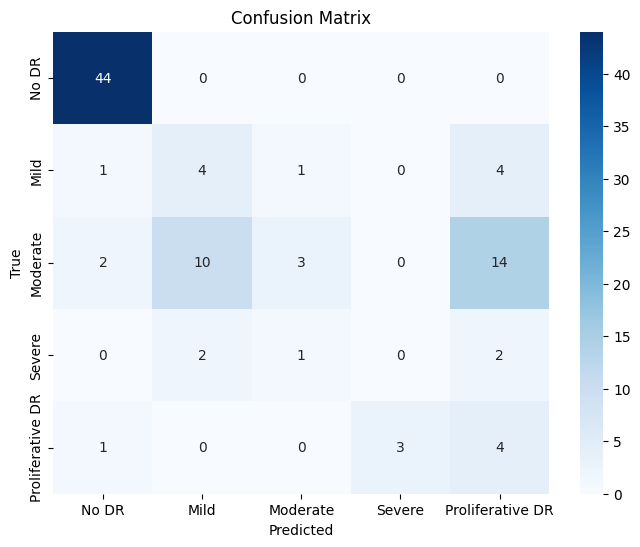

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 5. Model Evaluation ---

if 'model' in locals():
    # Evaluate the model on the test set
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f"Test Accuracy: {accuracy * 100:.2f}%")

    # Generate predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Classification Report
    print("\nClassification Report:")
    target_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
    print(classification_report(y_true, y_pred_classes, target_names=target_names))

    # Confusion Matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

else:
    print("Model not trained. Skipping evaluation.")

In [8]:
# --- 6. Save the Model ---

if 'model' in locals():
    # Save the trained model in the recommended Keras format
    model.save('../model/cnn_retinopathy_model.keras')
    print("Model saved to model/cnn_retinopathy_model.keras")
else:
    print("Model not trained. Skipping model saving.")

Model saved to model/cnn_retinopathy_model.keras
